In [1]:
from pathlib import Path
import sys


def find_repository_root() -> Path:
    
    candidate = Path.cwd().resolve()

    while candidate != candidate.parent:

        if ((candidate / "app").is_dir() and (candidate / "notebooks").is_dir()):
            
            return candidate

        candidate = candidate.parent

    raise RuntimeError("Could not locate reconciliation_engine repository root.")

PROJECT_ROOT = find_repository_root()

if str(PROJECT_ROOT) not in sys.path:
    
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Repository root: {PROJECT_ROOT}")

Repository root: C:\Users\ASUS\Desktop\Projects\reconciliation_engine


In [2]:
from pathlib import Path

import pandas as pd

from app.core.config import settings
from app.reporting.report_generator import ReportGenerator
from app.services.reconciliation_service import ReconciliationService
from app.services.fuzzy_match_service import fuzzy_match_field
from IPython.display import Image

In [3]:
class DemoSalesClient:

    def get_sales_records(self):

        return pd.DataFrame([
                {
                    "transaction_id": "101",
                    "invoice_number": "INV-2026-000101",
                    "product_id": "10",
                    "quantity": "5",
                    "status": "VALIDATED",
                    "created_at": "2026-08-08T09:00:00Z"
                },
                {
                    "transaction_id": "102",
                    "invoice_number": "INV-2026-000102",
                    "product_id": "11",
                    "quantity": "10",
                    "status": "COMPLETED",
                    "created_at": "2026-08-08T10:00:00Z"
                },
                {
                    "transaction_id": "103",
                    "invoice_number": "INV-2026-000103",
                    "product_id": "12",
                    "quantity": "5",
                    "status": "VALIDATED",
                    "created_at": "2026-08-08T11:00:00Z"
                },
                {
                    "transaction_id": "104",
                    "invoice_number": "INV-2026-000104",
                    "product_id": "13",
                    "quantity": "3",
                    "status": "VALIDATED",
                    "created_at": "2026-08-08T12:00:00Z"
                }])

In [4]:
class DemoInventoryClient:

    def get_inventory_records(self):

        return pd.DataFrame([
                # MATCHED
                {
                    "transaction_id": "101",
                    "reservation_id": "501",
                    "batch_id": "20",
                    "reserved_quantity": "5",
                    "status": "RESERVED",
                    "reserved_at": "2026-08-08T09:01:00Z"
                },
                # QUANTITY_MISMATCH
                {
                    "transaction_id": "102",
                    "reservation_id": "502",
                    "batch_id": "21",
                    "reserved_quantity": "7",
                    "status": "RESERVED",
                    "reserved_at": "2026-08-08T10:01:00Z"
                },
                # DUPLICATE_RESERVATION
                {
                    "transaction_id": "103",
                    "reservation_id": "503",
                    "batch_id": "22",
                    "reserved_quantity": "3",
                    "status": "RESERVED",
                    "reserved_at": "2026-08-08T11:01:00Z"
                },
                {
                    "transaction_id": "103",
                    "reservation_id": "504",
                    "batch_id": "23",
                    "reserved_quantity": "2",
                    "status": "RESERVED",
                    "reserved_at": "2026-08-08T11:02:00Z"
                },
                # ORPHAN_RESERVATION
                {
                    "transaction_id": "105",
                    "reservation_id": "505",
                    "batch_id": "24",
                    "reserved_quantity": "6",
                    "status": "RESERVED",
                    "reserved_at": "2026-08-08T13:01:00Z"
                }])

In [5]:
sales_client = DemoSalesClient()
inventory_client = DemoInventoryClient()

settings.reports_dir = (PROJECT_ROOT / "notebooks" / "reports").resolve()

settings.charts_dir = (settings.reports_dir / "charts").resolve()

report_generator = ReportGenerator()

service = ReconciliationService(
    sales_client=sales_client,
    inventory_client=inventory_client,
    report_generator=report_generator
)

In [6]:
result = service.run()

result.keys()

dict_keys(['run_metadata', 'source_df', 'target_df', 'comparison_results', 'comparison_df', 'mismatches', 'fuzzy_matches', 'summary_df'])

In [7]:
run_metadata = result["run_metadata"]

source_metadata = run_metadata["source"]
target_metadata = run_metadata["target"]
reconciliation_metadata = run_metadata["reconciliation"]

print("=" * 80)
print("RECONCILIATION RUN")
print("=" * 80)

print(f"Run ID:         {run_metadata['run_id']}")
print(f"Execution time: {run_metadata['execution_time']}")
print()

print("RECONCILED DATASETS")
print("-" * 80)

print("SOURCE")
print(f"  Project:       {source_metadata['project']}")
print(f"  Service:       {source_metadata['service']}")
print(f"  Endpoint:      GET {source_metadata['endpoint']}")
print(f"  Records:       {source_metadata['records_retrieved']}")
print()

print("TARGET")
print(f"  Project:       {target_metadata['project']}")
print(f"  Service:       {target_metadata['service']}")
print(f"  Endpoint:      GET {target_metadata['endpoint']}")
print(f"  Records:       {target_metadata['records_retrieved']}")
print()

print("COMPARISON")
print("-" * 80)
print(f"  Comparison key: {reconciliation_metadata['comparison_key']}")
print(f"  Source system:  {reconciliation_metadata['source_system']}")
print(f"  Target system:  {reconciliation_metadata['target_system']}")
print()

print("PROJECT 1 AUTHENTICATION")
print("-" * 80)
print("Project 1 — Authentication Service")
print("Role: infrastructure / identity / authorization")
print("Reconciled dataset: NO")

RECONCILIATION RUN
Run ID:         REC-20260812-094135-AF9ADEFD
Execution time: 2026-08-12T09:41:35.775643+00:00

RECONCILED DATASETS
--------------------------------------------------------------------------------
SOURCE
  Project:       Project 3 — Sales Transaction Service
  Service:       Sales Transaction Service
  Endpoint:      GET /internal/transactions
  Records:       4

TARGET
  Project:       Project 2 — Inventory Dispatch System
  Service:       Inventory Dispatch System
  Endpoint:      GET /reservations/reconciliation
  Records:       5

COMPARISON
--------------------------------------------------------------------------------
  Comparison key: transaction_id
  Source system:  Project 3 — Sales Transaction Service
  Target system:  Project 2 — Inventory Dispatch System

PROJECT 1 AUTHENTICATION
--------------------------------------------------------------------------------
Project 1 — Authentication Service
Role: infrastructure / identity / authorization
Reconciled dat

In [8]:
print("=" * 80)
print("SOURCE DATA — PROJECT 3 SALES TRANSACTION SERVICE")
print("=" * 80)

sales_columns = ["transaction_id",
                 "invoice_number",
                 "product_id",
                 "quantity",
                 "status",
                 "created_at"]

assert source_metadata["project"] == "Project 3 — Sales Transaction Service"
assert source_metadata["endpoint"] == "/internal/transactions"
assert source_metadata["records_retrieved"] == len(result["source_df"])

assert set(source_metadata["fields"]) == set(sales_columns)
assert list(result["source_df"].columns) == sales_columns

print("Project:  Project 3 — Sales Transaction Service")
print("Endpoint: GET /internal/transactions")
print(f"Records:  {len(result['source_df'])}")
print()
print("Contract:")
for field in sales_columns:
    
    print(f"  - {field}")

print()
print("Representative Sales records:")
display(result["source_df"].head())

SOURCE DATA — PROJECT 3 SALES TRANSACTION SERVICE
Project:  Project 3 — Sales Transaction Service
Endpoint: GET /internal/transactions
Records:  4

Contract:
  - transaction_id
  - invoice_number
  - product_id
  - quantity
  - status
  - created_at

Representative Sales records:


,transaction_id,invoice_number,product_id,quantity,status,created_at
0,101,INV-2026-000101,10,5,VALIDATED,2026-08-08 09:00:00+00:00
1,102,INV-2026-000102,11,10,COMPLETED,2026-08-08 10:00:00+00:00
2,103,INV-2026-000103,12,5,VALIDATED,2026-08-08 11:00:00+00:00
3,104,INV-2026-000104,13,3,VALIDATED,2026-08-08 12:00:00+00:00


In [9]:
print("=" * 80)
print("TARGET DATA — PROJECT 2 INVENTORY DISPATCH SYSTEM")
print("=" * 80)

inventory_columns = [
    "transaction_id",
    "reservation_id",
    "batch_id",
    "reserved_quantity",
    "status",
    "reserved_at",
]

assert target_metadata["project"] == "Project 2 — Inventory Dispatch System"
assert target_metadata["endpoint"] == "/reservations/reconciliation"
assert target_metadata["records_retrieved"] == len(result["target_df"])

assert set(target_metadata["fields"]) == set(inventory_columns)
assert list(result["target_df"].columns) == inventory_columns

print("Project:  Project 2 — Inventory Dispatch System")
print("Endpoint: GET /reservations/reconciliation")
print(f"Records:  {len(result['target_df'])}")
print()
print("Contract:")
for field in inventory_columns:
    print(f"  - {field}")

print()
print("Representative Inventory reservation records:")
display(result["target_df"].head())

TARGET DATA — PROJECT 2 INVENTORY DISPATCH SYSTEM
Project:  Project 2 — Inventory Dispatch System
Endpoint: GET /reservations/reconciliation
Records:  5

Contract:
  - transaction_id
  - reservation_id
  - batch_id
  - reserved_quantity
  - status
  - reserved_at

Representative Inventory reservation records:


,transaction_id,reservation_id,batch_id,reserved_quantity,status,reserved_at
0,101,501,20,5,RESERVED,2026-08-08 09:01:00+00:00
1,102,502,21,7,RESERVED,2026-08-08 10:01:00+00:00
2,103,503,22,3,RESERVED,2026-08-08 11:01:00+00:00
3,103,504,23,2,RESERVED,2026-08-08 11:02:00+00:00
4,105,505,24,6,RESERVED,2026-08-08 13:01:00+00:00


In [10]:
print("=" * 80)
print("DATA OWNERSHIP")
print("=" * 80)

print("Project 1 — Authentication Service")
print("  Infrastructure only.")
print("  Provides identity and authorization.")
print("  NOT reconciled.")

print()

print("Project 2 — Inventory Dispatch System")
print("  Authoritative owner of inventory reservation data.")
print("  Reconciled as TARGET.")

print()

print("Project 3 — Sales Transaction Service")
print("  Authoritative owner of sales transaction data.")
print("  Reconciled as SOURCE.")

print()

print("Project 4 — Reconciliation Automation Engine")
print("  Consumes Project 3 and Project 2 data.")
print("  Performs comparison and discrepancy detection.")
print("  Produces reconciliation reports and analytics.")

DATA OWNERSHIP
Project 1 — Authentication Service
  Infrastructure only.
  Provides identity and authorization.
  NOT reconciled.

Project 2 — Inventory Dispatch System
  Authoritative owner of inventory reservation data.
  Reconciled as TARGET.

Project 3 — Sales Transaction Service
  Authoritative owner of sales transaction data.
  Reconciled as SOURCE.

Project 4 — Reconciliation Automation Engine
  Consumes Project 3 and Project 2 data.
  Performs comparison and discrepancy detection.
  Produces reconciliation reports and analytics.


In [11]:
print("=" * 80)
print("RECONCILIATION RESULTS")
print("=" * 80)

print("Comparison:")
print("  Project 3 — Sales Transaction Service")
print("              VS")
print("  Project 2 — Inventory Dispatch System")
print()
print("Comparison key: transaction_id")
print()

display(result["comparison_df"])

RECONCILIATION RESULTS
Comparison:
  Project 3 — Sales Transaction Service
              VS
  Project 2 — Inventory Dispatch System

Comparison key: transaction_id



,source_system,target_system,comparison_key,comparison_scope,sales_record_present,inventory_record_present,transaction_id,invoice_number,status,mismatch_type,...,reservation_id,batch_id,reservation_ids,batch_ids,reserved_quantities,reservation_statuses,reservation_timestamps,reservations,sales_quantity,details
0,Project 3 — Sales Transaction Service,Project 2 — Inventory Dispatch System,transaction_id,Sales transactions compared against Inventory ...,True,True,101,INV-2026-000101,MATCHED,NaN,...,501,20,[501],[20],[5],[RESERVED],[2026-08-08 09:01:00+00:00],"[{'reservation_id': '501', 'batch_id': '20', '...",NaN,NaN
1,Project 3 — Sales Transaction Service,Project 2 — Inventory Dispatch System,transaction_id,Sales transactions compared against Inventory ...,True,True,102,INV-2026-000102,MISMATCHED,QUANTITY_MISMATCH,...,502,21,[502],[21],[7],[RESERVED],[2026-08-08 10:01:00+00:00],"[{'reservation_id': '502', 'batch_id': '21', '...",10.0,Sales transaction quantity does not match Inve...
2,Project 3 — Sales Transaction Service,Project 2 — Inventory Dispatch System,transaction_id,Sales transactions compared against Inventory ...,True,True,103,NaN,MISMATCHED,DUPLICATE_RESERVATION,...,NaN,NaN,"[503, 504]","[22, 23]","[3, 2]","[RESERVED, RESERVED]","[2026-08-08 11:01:00+00:00, 2026-08-08 11:02:0...","[{'reservation_id': '503', 'batch_id': '22', '...",NaN,Multiple Inventory reservations exist for the ...
3,Project 3 — Sales Transaction Service,Project 2 — Inventory Dispatch System,transaction_id,Sales transactions compared against Inventory ...,True,False,104,INV-2026-000104,MISMATCHED,MISSING_RESERVATION,...,NaN,NaN,[],[],[],[],[],NaN,3.0,Sales transaction has no corresponding Invento...
4,Project 3 — Sales Transaction Service,Project 2 — Inventory Dispatch System,transaction_id,Sales transactions compared against Inventory ...,False,True,105,NaN,MISMATCHED,ORPHAN_RESERVATION,...,NaN,NaN,[505],[24],[6],[RESERVED],[2026-08-08 13:01:00+00:00],"[{'reservation_id': '505', 'batch_id': '24', '...",NaN,Inventory reservation references a transaction...


In [12]:
results_by_transaction = {int(result["transaction_id"]): result for result in result["comparison_results"]}

assert (results_by_transaction[102]["mismatch_type"] == "QUANTITY_MISMATCH")

assert (results_by_transaction[103]["mismatch_type"] == "DUPLICATE_RESERVATION")

assert (results_by_transaction[104]["mismatch_type"] == "MISSING_RESERVATION")

assert (results_by_transaction[105]["mismatch_type"] == "ORPHAN_RESERVATION")

print("All required discrepancy classifications verified.")

All required discrepancy classifications verified.


In [13]:
duplicate_result = results_by_transaction[103]

assert duplicate_result["mismatch_type"] == ("DUPLICATE_RESERVATION")

assert duplicate_result["reservation_count"] == 2

assert duplicate_result["reservation_ids"] == ["503", "504"]

assert duplicate_result["reserved_quantities"] == [3, 2]

print("Duplicate reservation preserved:", duplicate_result["reservation_ids"])

Duplicate reservation preserved: ['503', '504']


In [14]:
assert isinstance(result["fuzzy_matches"], dict)

assert result["fuzzy_matches"] == {}

print("Fuzzy-matching stage executed.")

print("No fuzzy matches were produced because the current Sales/Inventory reconciliation contracts contain no supported shared textual field.")

Fuzzy-matching stage executed.
No fuzzy matches were produced because the current Sales/Inventory reconciliation contracts contain no supported shared textual field.


In [15]:
fuzzy_result = fuzzy_match_field("ABC Corporation", "ABC Corp", field_name="secondary_text", threshold=65)

display(pd.DataFrame([fuzzy_result]))

assert fuzzy_result["field"] == "secondary_text"
assert fuzzy_result["matched"] is True
assert fuzzy_result["threshold"] == 65
assert fuzzy_result["score"] >= 65

,field,left_value,right_value,score,threshold,matched
0,secondary_text,ABC Corporation,ABC Corp,69.565217,65,True


In [16]:
display(pd.DataFrame(result["mismatches"]))

,transaction_id,mismatch_type,invoice_number,sales_quantity,reserved_quantity,reservation_count,reservation_id,batch_id,reservation_ids,batch_ids,reserved_quantities,reservation_statuses,reservation_timestamps,details,reservations
0,104,MISSING_RESERVATION,INV-2026-000104,3.0,NaN,0,NaN,NaN,[],[],[],[],[],Sales transaction has no corresponding Invento...,NaN
1,103,DUPLICATE_RESERVATION,NaN,NaN,5.0,2,NaN,NaN,"[503, 504]","[22, 23]","[3, 2]","[RESERVED, RESERVED]","[2026-08-08 11:01:00+00:00, 2026-08-08 11:02:0...",Multiple Inventory reservations exist for the ...,"[{'reservation_id': '503', 'batch_id': '22', '..."
2,102,QUANTITY_MISMATCH,INV-2026-000102,10.0,7.0,1,502,21,[502],[21],[7],[RESERVED],[2026-08-08 10:01:00+00:00],Sales transaction quantity does not match Inve...,"[{'reservation_id': '502', 'batch_id': '21', '..."
3,105,ORPHAN_RESERVATION,NaN,NaN,6.0,1,NaN,NaN,[505],[24],[6],[RESERVED],[2026-08-08 13:01:00+00:00],Inventory reservation references a transaction...,"[{'reservation_id': '505', 'batch_id': '24', '..."


In [17]:
print("=" * 80)
print("RECONCILIATION SUMMARY")
print("=" * 80)

print("SOURCE:")
print("  Project 3 — Sales Transaction Service")
print(f"  Records: {source_metadata['records_retrieved']}")

print()

print("TARGET:")
print("  Project 2 — Inventory Dispatch System")
print(f"  Records: {target_metadata['records_retrieved']}")

print()

print("COMPARISON KEY:")
print("  transaction_id")

print()

print("RESULT DEFINITIONS:")
print("  MATCHED     = Sales transaction has a corresponding Inventory reservation with no detected discrepancy.")
print("  MISMATCHED  = Corresponding records exist but a reconciliation discrepancy was detected.")
print("  MISSING     = A Sales transaction has no corresponding Inventory reservation.")

print()

display(result["summary_df"])

RECONCILIATION SUMMARY
SOURCE:
  Project 3 — Sales Transaction Service
  Records: 4

TARGET:
  Project 2 — Inventory Dispatch System
  Records: 5

COMPARISON KEY:
  transaction_id

RESULT DEFINITIONS:
  MATCHED     = Sales transaction has a corresponding Inventory reservation with no detected discrepancy.
  MISMATCHED  = Corresponding records exist but a reconciliation discrepancy was detected.
  MISSING     = A Sales transaction has no corresponding Inventory reservation.



,category_type,category,count,definition,source_system,source_endpoint,source_record_count,target_system,target_endpoint,target_record_count,comparison_key
0,status,MISMATCHED,4,Sales transaction and Inventory reservation pa...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id
1,status,MATCHED,1,Sales transaction has a corresponding Inventor...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id
2,mismatch_type,QUANTITY_MISMATCH,1,Sales quantity differs from the corresponding ...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id
3,mismatch_type,DUPLICATE_RESERVATION,1,More than one Inventory reservation exists for...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id
4,mismatch_type,MISSING_RESERVATION,1,A Sales transaction has no corresponding Inven...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id
5,mismatch_type,ORPHAN_RESERVATION,1,An Inventory reservation has no corresponding ...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id


In [18]:
REPORT_DIR = (PROJECT_ROOT / "notebooks" / "reports").resolve()

CHART_DIR = (REPORT_DIR / "charts").resolve()

expected_reports = [
    REPORT_DIR / "matched.csv",
    REPORT_DIR / "mismatched.csv",
    REPORT_DIR / "missing.csv",
    REPORT_DIR / "summary.csv",
]

expected_chart = (CHART_DIR / "reconciliation_summary.png")

for path in expected_reports:
    
    print(path)

print(expected_chart)

C:\Users\ASUS\Desktop\Projects\reconciliation_engine\notebooks\reports\matched.csv
C:\Users\ASUS\Desktop\Projects\reconciliation_engine\notebooks\reports\mismatched.csv
C:\Users\ASUS\Desktop\Projects\reconciliation_engine\notebooks\reports\missing.csv
C:\Users\ASUS\Desktop\Projects\reconciliation_engine\notebooks\reports\summary.csv
C:\Users\ASUS\Desktop\Projects\reconciliation_engine\notebooks\reports\charts\reconciliation_summary.png


In [19]:
for report_path in expected_reports:

    assert report_path.exists(), (f"Missing report: {report_path}")

assert expected_chart.exists(), (f"Missing chart: {expected_chart}")

print("All reconciliation reports and analytics chart exist.")

All reconciliation reports and analytics chart exist.


In [20]:
for report_path in expected_reports:

    print(f"\n--- {report_path.name} ---")

    display(pd.read_csv(report_path))


--- matched.csv ---


,run_id,source_endpoint,target_endpoint,report_type,source_system,target_system,comparison_key,comparison_scope,sales_record_present,inventory_record_present,...,reserved_quantity,reservation_count,reservation_id,batch_id,reservation_ids,batch_ids,reserved_quantities,reservation_statuses,reservation_timestamps,reservations
0,REC-20260812-094135-AF9ADEFD,/internal/transactions,/reservations/reconciliation,MATCHED,Project 3 — Sales Transaction Service,Project 2 — Inventory Dispatch System,transaction_id,Sales transactions compared against Inventory ...,True,True,...,5,1,501,20,"[""501""]","[""20""]",[5],"[""RESERVED""]","[""2026-08-08 09:01:00+00:00""]","[{""reservation_id"": ""501"", ""batch_id"": ""20"", ""..."



--- mismatched.csv ---


,run_id,source_endpoint,target_endpoint,report_type,source_system,target_system,comparison_key,comparison_scope,sales_record_present,inventory_record_present,...,reservation_id,batch_id,reservation_ids,batch_ids,reserved_quantities,reservation_statuses,reservation_timestamps,reservations,sales_quantity,details
0,REC-20260812-094135-AF9ADEFD,/internal/transactions,/reservations/reconciliation,MISMATCHED,Project 3 — Sales Transaction Service,Project 2 — Inventory Dispatch System,transaction_id,Sales transactions compared against Inventory ...,True,True,...,502.0,21.0,"[""502""]","[""21""]","[""7""]","[""RESERVED""]","[""2026-08-08 10:01:00+00:00""]","[{""reservation_id"": ""502"", ""batch_id"": ""21"", ""...",10.0,Sales transaction quantity does not match Inve...
1,REC-20260812-094135-AF9ADEFD,/internal/transactions,/reservations/reconciliation,MISMATCHED,Project 3 — Sales Transaction Service,Project 2 — Inventory Dispatch System,transaction_id,Sales transactions compared against Inventory ...,True,True,...,NaN,NaN,"[""503"", ""504""]","[""22"", ""23""]","[3, 2]","[""RESERVED"", ""RESERVED""]","[""2026-08-08 11:01:00+00:00"", ""2026-08-08 11:0...","[{""reservation_id"": ""503"", ""batch_id"": ""22"", ""...",NaN,Multiple Inventory reservations exist for the ...
2,REC-20260812-094135-AF9ADEFD,/internal/transactions,/reservations/reconciliation,MISMATCHED,Project 3 — Sales Transaction Service,Project 2 — Inventory Dispatch System,transaction_id,Sales transactions compared against Inventory ...,False,True,...,NaN,NaN,"[""505""]","[""24""]",[6],"[""RESERVED""]","[""2026-08-08 13:01:00+00:00""]","[{""reservation_id"": ""505"", ""batch_id"": ""24"", ""...",NaN,Inventory reservation references a transaction...



--- missing.csv ---


,run_id,source_endpoint,target_endpoint,report_type,source_system,target_system,comparison_key,comparison_scope,sales_record_present,inventory_record_present,...,reservation_count,reservation_id,batch_id,reservation_ids,batch_ids,reserved_quantities,reservation_statuses,reservation_timestamps,sales_quantity,details
0,REC-20260812-094135-AF9ADEFD,/internal/transactions,/reservations/reconciliation,MISSING,Project 3 — Sales Transaction Service,Project 2 — Inventory Dispatch System,transaction_id,Sales transactions compared against Inventory ...,True,False,...,0,NaN,NaN,[],[],[],[],[],3,Sales transaction has no corresponding Invento...



--- summary.csv ---


,category_type,category,count,definition,source_system,source_endpoint,source_record_count,target_system,target_endpoint,target_record_count,comparison_key
0,status,MISMATCHED,4,Sales transaction and Inventory reservation pa...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id
1,status,MATCHED,1,Sales transaction has a corresponding Inventor...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id
2,mismatch_type,QUANTITY_MISMATCH,1,Sales quantity differs from the corresponding ...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id
3,mismatch_type,DUPLICATE_RESERVATION,1,More than one Inventory reservation exists for...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id
4,mismatch_type,MISSING_RESERVATION,1,A Sales transaction has no corresponding Inven...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id
5,mismatch_type,ORPHAN_RESERVATION,1,An Inventory reservation has no corresponding ...,Project 3 — Sales Transaction Service,/internal/transactions,4,Project 2 — Inventory Dispatch System,/reservations/reconciliation,5,transaction_id


In [21]:
matched_df = pd.read_csv(REPORT_DIR / "matched.csv")

mismatched_df = pd.read_csv(REPORT_DIR / "mismatched.csv")

missing_df = pd.read_csv(REPORT_DIR / "missing.csv")

assert set(mismatched_df["mismatch_type"]) == {"QUANTITY_MISMATCH",
                                               "DUPLICATE_RESERVATION",
                                               "ORPHAN_RESERVATION"}

assert set(missing_df["mismatch_type"]) == {"MISSING_RESERVATION"}

for dataframe in [matched_df, mismatched_df, missing_df]:

    assert set(dataframe["source_system"]) == {"Project 3 — Sales Transaction Service"}

    assert set(dataframe["target_system"]) == {"Project 2 — Inventory Dispatch System"}

    assert set(dataframe["comparison_key"]) == {"transaction_id"}

print("Detailed mismatch classifications survived report serialization.")
print("Report provenance survived CSV serialization.")

Detailed mismatch classifications survived report serialization.
Report provenance survived CSV serialization.


RECONCILIATION CHART
Project 3 — Sales Transaction Service
        VS
Project 2 — Inventory Dispatch System
Comparison key: transaction_id



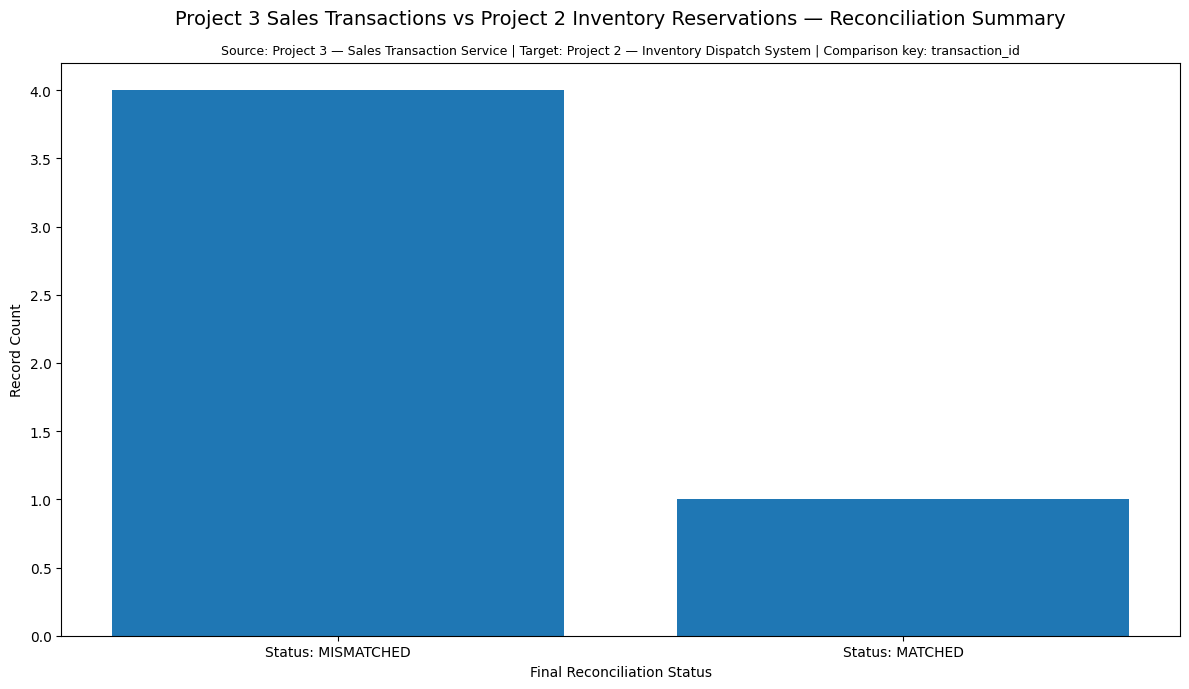

In [22]:
print("=" * 80)
print("RECONCILIATION CHART")
print("=" * 80)

print("Project 3 — Sales Transaction Service")
print("        VS")
print("Project 2 — Inventory Dispatch System")
print("Comparison key: transaction_id")
print()

display(Image(filename=str(expected_chart)))

In [23]:
report_results = pd.concat([pd.read_csv(REPORT_DIR / "matched.csv"),
                            pd.read_csv(REPORT_DIR / "mismatched.csv"),
                            pd.read_csv(REPORT_DIR / "missing.csv")],
                            ignore_index=True)

assert set(report_results["transaction_id"]) == {101, 102, 103, 104, 105}

assert len(report_results) == 5

assert len(pd.read_csv(REPORT_DIR / "matched.csv")) == 1

assert len(pd.read_csv(REPORT_DIR / "mismatched.csv")) == 3

assert len(pd.read_csv(REPORT_DIR / "missing.csv")) == 1

print("Reconciliation demonstration completed successfully.")
print(f"Reports: {REPORT_DIR}")
print(f"Chart: {expected_chart}")

Reconciliation demonstration completed successfully.
Reports: C:\Users\ASUS\Desktop\Projects\reconciliation_engine\notebooks\reports
Chart: C:\Users\ASUS\Desktop\Projects\reconciliation_engine\notebooks\reports\charts\reconciliation_summary.png
